# Exercise 4 – Real World: Quantum Full Adder

Implement a classical full-adder circuit using CNOT and Toffoli gates.

A full adder adds three binary inputs: A, B and Carry-in, and produces Sum and Carry-out. CNOT is used for XOR operations and Toffoli is used for carry calculation.

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_state_qsphere,
    plot_state_city,
    plot_histogram
)
from qiskit_aer import AerSimulator
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

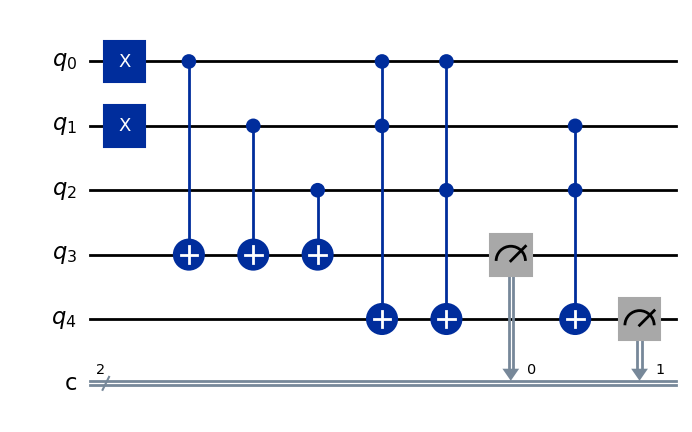

Input: A=1, B=1, Carry-in=0
Result: {'10': 1024}


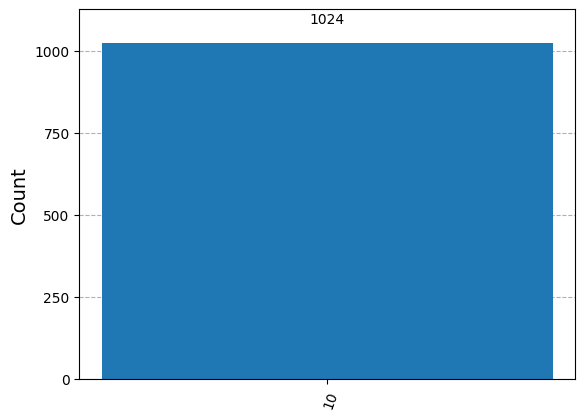

In [5]:
from qiskit_aer import AerSimulator

def full_adder(a, b, cin):
    qc = QuantumCircuit(5, 2)

    if a: qc.x(0)
    if b: qc.x(1)
    if cin: qc.x(2)

    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    qc.ccx(0, 1, 4)
    qc.ccx(0, 2, 4)
    qc.ccx(1, 2, 4)

    qc.measure(3, 0)
    qc.measure(4, 1)

    return qc

qc4 = full_adder(1, 1, 0)

display(qc4.draw("mpl"))

counts4 = AerSimulator().run(qc4, shots=1024).result().get_counts()

print("Input: A=1, B=1, Carry-in=0")
print("Result:", counts4)

display(plot_histogram(counts4))

### Observation

For A = 1, B = 1 and Carry-in = 0, the full adder produced Sum = 0 and Carry = 1. The CNOT and Toffoli gates successfully performed the addition.